In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mingangolo/tracker/database.sqlite


In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

conn = sqlite3.connect('/kaggle/input/datasets/mingangolo/tracker/database.sqlite')

matches = pd.read_sql("SELECT * FROM Match", conn)
teams = pd.read_sql("SELECT * FROM Team", conn)

# Clean matches
cols_to_keep = [
    'id', 'season', 'stage', 'date',
    'home_team_api_id', 'away_team_api_id',
    'home_team_goal', 'away_team_goal'
]
matches = matches[cols_to_keep]
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date')

print(f"Ready! {len(matches)} matches loaded")

Ready! 25979 matches loaded


In [3]:
def get_team_form(team_name, season=None):
    # Find team
    team = teams[teams['team_long_name'].str.contains(team_name, case=False)]
    
    if team.empty:
        print(f"Team '{team_name}' not found!")
        return
    
    team_id = team.iloc[0]['team_api_id']
    team_full_name = team.iloc[0]['team_long_name']
    
    # Get all matches for this team
    home_matches = matches[matches['home_team_api_id'] == team_id].copy()
    away_matches = matches[matches['away_team_api_id'] == team_id].copy()
    
    # Add result from team perspective
    home_matches['result'] = home_matches.apply(
        lambda r: 'W' if r['home_team_goal'] > r['away_team_goal']
        else ('L' if r['home_team_goal'] < r['away_team_goal'] else 'D'), axis=1)
    home_matches['goals_for'] = home_matches['home_team_goal']
    home_matches['goals_against'] = home_matches['away_team_goal']
    
    away_matches['result'] = away_matches.apply(
        lambda r: 'W' if r['away_team_goal'] > r['home_team_goal']
        else ('L' if r['away_team_goal'] < r['home_team_goal'] else 'D'), axis=1)
    away_matches['goals_for'] = away_matches['away_team_goal']
    away_matches['goals_against'] = away_matches['home_team_goal']
    
    # Combine and sort
    team_matches = pd.concat([home_matches, away_matches]).sort_values('date')
    
    # Filter by season if provided
    if season:
        team_matches = team_matches[team_matches['season'] == season]
    
    # Calculate points
    team_matches['points'] = team_matches['result'].map({'W': 3, 'D': 1, 'L': 0})
    
    # Rolling form (last 5 matches)
    team_matches['form_5'] = team_matches['points'].rolling(5).mean().round(2)
    
    # Cumulative points
    team_matches['cumulative_points'] = team_matches['points'].cumsum()
    
    # Reset index
    team_matches = team_matches.reset_index(drop=True)
    team_matches['match_number'] = team_matches.index + 1
    
    return team_matches, team_full_name

print("Function ready!")

Function ready!


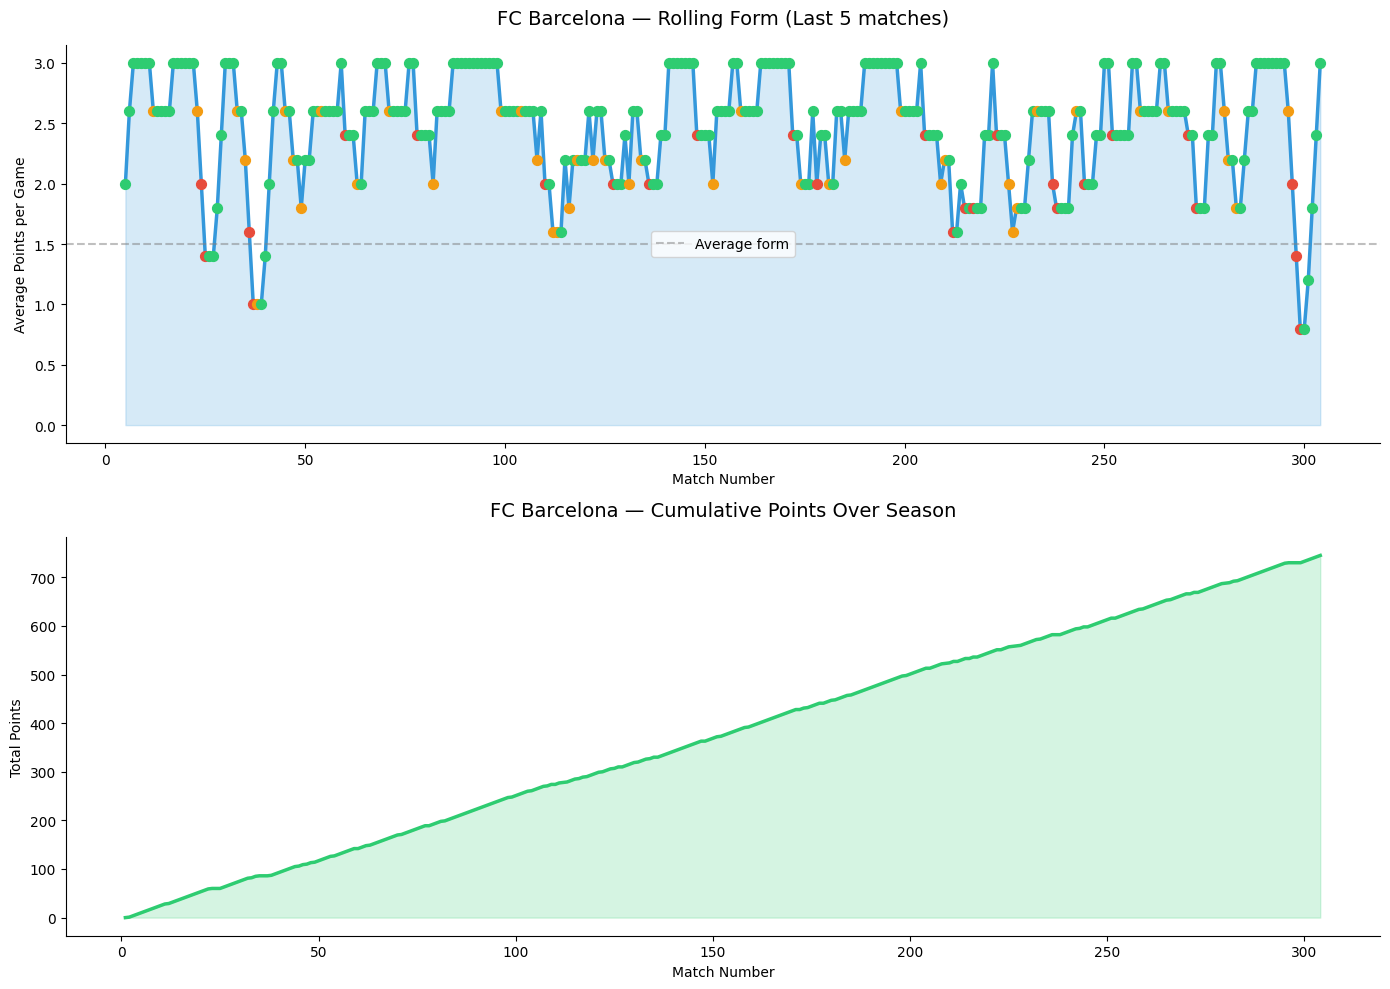


FC Barcelona Summary
Matches played: 304
Wins:           234 (77.0%)
Draws:          43 (14.1%)
Losses:         27 (8.9%)
Total points:   745
Points per game:2.45


In [4]:
def plot_team_form(team_name, season=None):
    data, full_name = get_team_form(team_name, season)
    
    if data is None:
        return
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1 — Rolling form
    ax1.plot(data['match_number'], data['form_5'], 
             linewidth=2.5, color='#3498db')
    ax1.fill_between(data['match_number'], data['form_5'], 
                     alpha=0.2, color='#3498db')
    ax1.axhline(y=1.5, color='gray', linestyle='--', alpha=0.5, label='Average form')
    ax1.set_title(f'{full_name} — Rolling Form (Last 5 matches)', fontsize=14, pad=15)
    ax1.set_xlabel('Match Number')
    ax1.set_ylabel('Average Points per Game')
    ax1.legend()
    
    # Color result dots
    colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}
    for _, row in data.iterrows():
        if pd.notna(row['form_5']):
            ax1.scatter(row['match_number'], row['form_5'],
                       color=colors[row['result']], s=50, zorder=5)
    
    # Plot 2 — Cumulative points
    ax2.plot(data['match_number'], data['cumulative_points'],
             linewidth=2.5, color='#2ecc71')
    ax2.fill_between(data['match_number'], data['cumulative_points'],
                     alpha=0.2, color='#2ecc71')
    ax2.set_title(f'{full_name} — Cumulative Points Over Season', fontsize=14, pad=15)
    ax2.set_xlabel('Match Number')
    ax2.set_ylabel('Total Points')
    
    plt.tight_layout()
    plt.savefig(f'form_{team_name.lower()}.png', dpi=150)
    plt.show()
    
    # Print summary
    total = len(data)
    wins = len(data[data['result'] == 'W'])
    draws = len(data[data['result'] == 'D'])
    losses = len(data[data['result'] == 'L'])
    
    print(f"\n{full_name} Summary")
    print(f"{'='*40}")
    print(f"Matches played: {total}")
    print(f"Wins:           {wins} ({wins/total*100:.1f}%)")
    print(f"Draws:          {draws} ({draws/total*100:.1f}%)")
    print(f"Losses:         {losses} ({losses/total*100:.1f}%)")
    print(f"Total points:   {data['cumulative_points'].iloc[-1]}")
    print(f"Points per game:{data['points'].mean():.2f}")

# Test with Barcelona
plot_team_form('Barcelona')

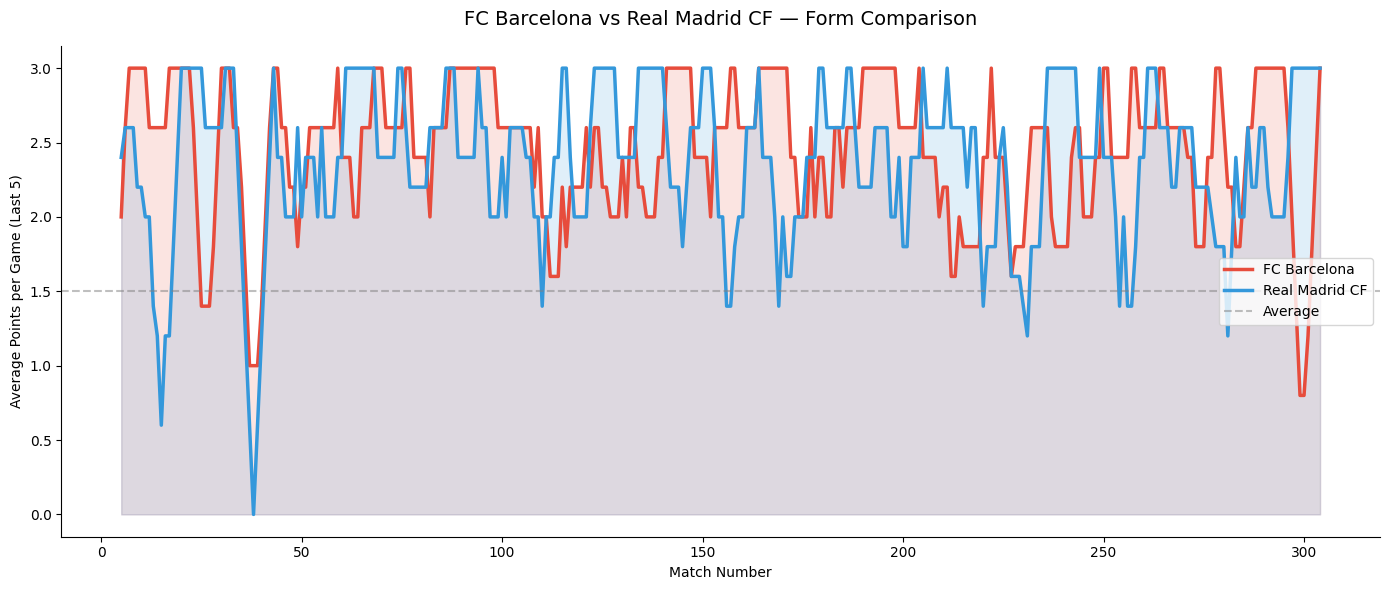


HEAD TO HEAD SUMMARY
Metric                    FC Barcelona    Real Madrid CF 
Win %                     77.0%           75.0%
Points per game           2.45            2.37
Total matches             304             304            


In [5]:
def compare_teams_form(team1_name, team2_name, season=None):
    data1, name1 = get_team_form(team1_name, season)
    data2, name2 = get_team_form(team2_name, season)

    if data1 is None or data2 is None:
        return

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(data1['match_number'], data1['form_5'],
            linewidth=2.5, color='#e74c3c', label=name1)
    ax.fill_between(data1['match_number'], data1['form_5'],
                    alpha=0.15, color='#e74c3c')

    ax.plot(data2['match_number'], data2['form_5'],
            linewidth=2.5, color='#3498db', label=name2)
    ax.fill_between(data2['match_number'], data2['form_5'],
                    alpha=0.15, color='#3498db')

    ax.axhline(y=1.5, color='gray', linestyle='--', alpha=0.5, label='Average')
    ax.set_title(f'{name1} vs {name2} — Form Comparison', fontsize=14, pad=15)
    ax.set_xlabel('Match Number')
    ax.set_ylabel('Average Points per Game (Last 5)')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'form_comparison.png', dpi=150)
    plt.show()

    # Head to head summary
    print(f"\nHEAD TO HEAD SUMMARY")
    print(f"{'='*45}")
    print(f"{'Metric':<25} {name1:<15} {name2:<15}")
    print(f"{'='*45}")
    print(f"{'Win %':<25} {len(data1[data1['result']=='W'])/len(data1)*100:.1f}%{'':<10} {len(data2[data2['result']=='W'])/len(data2)*100:.1f}%")
    print(f"{'Points per game':<25} {data1['points'].mean():.2f}{'':<11} {data2['points'].mean():.2f}")
    print(f"{'Total matches':<25} {len(data1):<15} {len(data2):<15}")

# Compare Barcelona vs Real Madrid
compare_teams_form('Barcelona', 'Real Madrid')

In [6]:
# Save form data for both teams
barca_data, _ = get_team_form('Barcelona')
madrid_data, _ = get_team_form('Real Madrid')

barca_data.to_csv('barcelona_form.csv', index=False)
madrid_data.to_csv('real_madrid_form.csv', index=False)

print("Saved!")
print(f"\nBarcelona matches: {len(barca_data)}")
print(f"Real Madrid matches: {len(madrid_data)}")

Saved!

Barcelona matches: 304
Real Madrid matches: 304
